# Salama Health Modelling Phase 2
LSTM + Random Forest + Weighted Ensemble CDI

| Model | Input | Captures |
|---|---|---|
| XGBoost Phase 1 | All 30 features | Tabular patterns |
| LSTM | 7-week climate sequences | Temporal patterns |
| Random Forest | Spatial and static features | Location patterns |
| Weighted Ensemble | AUC-weighted average of all 3 | Combines all signals |

Output: Final ensemble CDI scores for all 93 facilities

## 0. Setup

In [26]:
!pip install numpy==1.26.4 -q
!pip install xgboost lightgbm scikit-learn shap -q
!pip install torch -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
import pickle
import json

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')

DATA_PATH  = '/kaggle/input/notebooks/mubarakabanadda/salama-health-data-download-pipeline/SSD_Training_Dataset_v2.csv'
MODEL_PATH = '/kaggle/input/datasets/mubarakabanadda/xgboost-model/SSD_XGBoost_Flood_Model.pkl'
OUT_DIR    = '/kaggle/working'

SEED   = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
np.random.seed(SEED)
torch.manual_seed(SEED)

print('Setup complete')
print(f'PyTorch: {torch.__version__}')
print(f'Device: {DEVICE}')

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
kaggle-environments 1.29.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
ydata-profiling 4.18.4 requires numba<0.63,>=0.60, but you have numba 0.65.1 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.

## 1. Load Data and Phase 1 Model

In [27]:
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['facility_name', 'date']).reset_index(drop=True)

with open(MODEL_PATH, 'rb') as f:
    xgb_model = pickle.load(f)

FEATURE_COLS = [
    'VV_backscatter', 'VV_7day_mean', 'VV_delta', 'flood_signal',
    'elevation_m', 'low_elevation',
    'chirps_rainfall_mm', 'chirps_anomaly', 'rainfall_roll30d',
    'rainfall_lag7d', 'rainfall_lag14d', 'rainfall_lag28d', 'rainfall_anomaly',
    'temp_max_celsius', 'temp_min_celsius', 'temp_anomaly',
    'temp_excess_8c', 'ccf_risk', 'cumulative_heat_7d', 'freeze_risk',
    'humidity_pct',
    'evapotranspiration', 'water_deficit', 'drought_signal',
    'idp_normalised',
    'season_sin', 'season_cos', 'rainy_season', 'month',
]
TARGET = 'disrupted'

for col in FEATURE_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

print(f'Dataset shape: {df.shape}')
print(f'Facilities: {df["facility_name"].nunique()}')
print(f'Disrupted: {df["disrupted"].sum():,} ({df["disrupted"].mean()*100:.2f}%)')
print('XGBoost model loaded')

Dataset shape: (9617, 41)
Facilities: 93
Disrupted: 474 (4.93%)
XGBoost model loaded


## 2. Train Test Split

In [28]:
train = df[df['date'].dt.year <= 2023].copy()
test  = df[df['date'].dt.year == 2024].copy()

X_train, y_train = train[FEATURE_COLS].values, train[TARGET].values
X_test,  y_test  = test[FEATURE_COLS].values,  test[TARGET].values

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)

print(f'Train: {len(train):,} rows | {int(y_train.sum())} disrupted')
print(f'Test:  {len(test):,} rows  | {int(y_test.sum())} disrupted')
print(f'scale pos weight: {scale_pos_weight:.1f}')

Train: 7,682 rows | 365 disrupted
Test:  1,935 rows  | 109 disrupted
scale pos weight: 20.0


## 3. LSTM on 7-Week Climate Sequences
LSTM captures temporal patterns such as rising rainfall over multiple weeks, sustained heat exposure, and seasonal flood onset.

In [29]:
LSTM_FEATURES = [
    'VV_backscatter', 'VV_7day_mean', 'VV_delta',
    'chirps_rainfall_mm', 'rainfall_roll30d', 'rainfall_anomaly',
    'temp_max_celsius', 'temp_excess_8c', 'ccf_risk',
    'humidity_pct', 'evapotranspiration', 'water_deficit',
    'season_sin', 'season_cos', 'rainy_season',
]

SEQ_LEN = 7

def build_sequences(data, seq_len, feature_cols, target_col):
    X_seqs, y_seqs, indices = [], [], []
    for facility, group in data.groupby('facility_name'):
        group   = group.sort_values('date').reset_index(drop=True)
        feats   = group[feature_cols].values
        targets = group[target_col].values
        for i in range(seq_len, len(group)):
            X_seqs.append(feats[i-seq_len:i])
            y_seqs.append(targets[i])
            indices.append(group.index[i])
    return np.array(X_seqs), np.array(y_seqs), indices

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[LSTM_FEATURES] = scaler.fit_transform(df[LSTM_FEATURES])

train_scaled = df_scaled[df_scaled['date'].dt.year <= 2023]
test_scaled  = df_scaled[df_scaled['date'].dt.year == 2024]

X_lstm_train, y_lstm_train, _ = build_sequences(train_scaled, SEQ_LEN, LSTM_FEATURES, TARGET)
X_lstm_test,  y_lstm_test,  _ = build_sequences(test_scaled,  SEQ_LEN, LSTM_FEATURES, TARGET)

print(f'LSTM train sequences: {X_lstm_train.shape}')
print(f'LSTM test sequences:  {X_lstm_test.shape}')
print(f'Sequence shape: {SEQ_LEN} weeks x {len(LSTM_FEATURES)} features')

LSTM train sequences: (7031, 7, 15)
LSTM test sequences:  (1501, 7, 15)
Sequence shape: 7 weeks x 15 features


In [30]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.3):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout
        )
        self.bn   = nn.BatchNorm1d(hidden_size)
        self.fc1  = nn.Linear(hidden_size, 32)
        self.relu = nn.ReLU()
        self.drop = nn.Dropout(dropout)
        self.fc2  = nn.Linear(32, 1)
        self.sig  = nn.Sigmoid()

    def forward(self, x):
        out, _ = self.lstm(x)
        out    = out[:, -1, :]
        out    = self.bn(out)
        out    = self.drop(self.relu(self.fc1(out)))
        return self.sig(self.fc2(out)).squeeze()


def train_lstm(X_tr, y_tr, X_val, y_val, n_features,
               epochs=50, batch_size=32, patience=10):
    pos_w     = float((y_tr == 0).sum() / max((y_tr == 1).sum(), 1))
    X_tr_t    = torch.FloatTensor(X_tr).to(DEVICE)
    y_tr_t    = torch.FloatTensor(y_tr).to(DEVICE)
    X_val_t   = torch.FloatTensor(X_val).to(DEVICE)
    y_val_t   = torch.FloatTensor(y_val).to(DEVICE)
    loader    = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                           batch_size=batch_size, shuffle=True)
    model     = LSTMModel(n_features).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, patience=5, factor=0.5)

    best_loss, best_state, no_improve = float('inf'), None, 0

    for epoch in range(epochs):
        model.train()
        for X_b, y_b in loader:
            optimizer.zero_grad()
            pred    = model(X_b)
            weights = torch.where(
                y_b == 1,
                torch.tensor(pos_w, device=DEVICE),
                torch.ones(1, device=DEVICE)
            )
            loss = (weights * nn.BCELoss(reduction='none')(pred, y_b)).mean()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = nn.BCELoss()(model(X_val_t), y_val_t).item()
        scheduler.step(val_loss)

        if val_loss < best_loss:
            best_loss  = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    model.load_state_dict(best_state)
    return model


lstm_model = train_lstm(
    X_lstm_train, y_lstm_train,
    X_lstm_test,  y_lstm_test,
    n_features = len(LSTM_FEATURES)
)

lstm_model.eval()
with torch.no_grad():
    lstm_proba_test = lstm_model(
        torch.FloatTensor(X_lstm_test).to(DEVICE)
    ).cpu().numpy()

lstm_pred_test = (lstm_proba_test > 0.5).astype(int)
lstm_auc = roc_auc_score(y_lstm_test, lstm_proba_test)
lstm_f1  = f1_score(y_lstm_test, lstm_pred_test, zero_division=0)

print(f'LSTM AUC: {lstm_auc:.4f}')
print(f'LSTM F1:  {lstm_f1:.4f}')

LSTM AUC: 0.9754
LSTM F1:  0.5562


## 4. Random Forest on Spatial Features
Random Forest captures location-based patterns such as which counties, elevations, and geographic positions are inherently more flood-prone.

In [31]:
RF_FEATURES = [
    'elevation_m', 'low_elevation', 'latitude', 'longitude',
    'chirps_rainfall_mm', 'rainfall_roll30d', 'chirps_anomaly',
    'temp_max_celsius', 'temp_excess_8c', 'ccf_risk',
    'idp_normalised', 'drought_signal', 'water_deficit',
    'rainy_season', 'month', 'season_sin', 'season_cos',
]

for col in ['latitude', 'longitude']:
    if col not in df.columns:
        df[col] = 0.0
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

X_rf_train = train[RF_FEATURES].fillna(0).values
X_rf_test  = test[RF_FEATURES].fillna(0).values

rf_model = RandomForestClassifier(
    n_estimators = 300,
    max_depth    = 8,
    class_weight = 'balanced',
    random_state = SEED,
    n_jobs       = -1
)
rf_model.fit(X_rf_train, y_train)

rf_proba_test = rf_model.predict_proba(X_rf_test)[:, 1]
rf_pred_test  = rf_model.predict(X_rf_test)

rf_auc = roc_auc_score(y_test, rf_proba_test)
rf_f1  = f1_score(y_test, rf_pred_test, zero_division=0)

print(f'Random Forest AUC: {rf_auc:.4f}')
print(f'Random Forest F1:  {rf_f1:.4f}')

rf_importance = pd.Series(
    rf_model.feature_importances_, index=RF_FEATURES
).sort_values(ascending=False)
print('\nTop 10 RF features:')
print(rf_importance.head(10).round(4))

Random Forest AUC: 0.9291
Random Forest F1:  0.4289

Top 10 RF features:
elevation_m         0.1594
longitude           0.1286
latitude            0.1236
rainy_season        0.1200
month               0.1026
season_sin          0.0800
season_cos          0.0671
rainfall_roll30d    0.0525
idp_normalised      0.0478
water_deficit       0.0237
dtype: float64


## 5. Out of Fold Predictions
Generate OOF predictions from all three models for ensemble weighting.

In [32]:
print('Generating out of fold predictions...')

X_full    = df[FEATURE_COLS].fillna(0).values
X_rf_full = df[RF_FEATURES].fillna(0).values
y_full    = df[TARGET].values

oof_xgb = np.zeros(len(df))
oof_rf  = np.zeros(len(df))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for fold, (tr_idx, val_idx) in enumerate(cv.split(X_full, y_full)):
    X_tr,   X_val   = X_full[tr_idx],    X_full[val_idx]
    Xrf_tr, Xrf_val = X_rf_full[tr_idx], X_rf_full[val_idx]
    y_tr,   y_val   = y_full[tr_idx],    y_full[val_idx]

    spw = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)

    xgb = XGBClassifier(
        n_estimators     = 200,
        max_depth        = 5,
        learning_rate    = 0.05,
        scale_pos_weight = spw,
        eval_metric      = 'auc',
        random_state     = SEED,
        verbosity        = 0
    )
    xgb.fit(X_tr, y_tr, verbose=False)
    oof_xgb[val_idx] = xgb.predict_proba(X_val)[:, 1]

    rf = RandomForestClassifier(
        n_estimators = 200,
        max_depth    = 8,
        class_weight = 'balanced',
        random_state = SEED,
        n_jobs       = -1
    )
    rf.fit(Xrf_tr, y_tr)
    oof_rf[val_idx] = rf.predict_proba(Xrf_val)[:, 1]

    print(f'Fold {fold+1} done')

print(f'\nOOF XGBoost AUC: {roc_auc_score(y_full, oof_xgb):.4f}')
print(f'OOF RF AUC:      {roc_auc_score(y_full, oof_rf):.4f}')

Generating out of fold predictions...
Fold 1 done
Fold 2 done
Fold 3 done
Fold 4 done
Fold 5 done

OOF XGBoost AUC: 1.0000
OOF RF AUC:      0.9548


## 6. LSTM Out of Fold Predictions

In [33]:
print('Generating LSTM out of fold predictions...')

X_lstm_full, y_lstm_full, lstm_indices = build_sequences(
    df_scaled, SEQ_LEN, LSTM_FEATURES, TARGET
)

oof_lstm = np.zeros(len(X_lstm_full))
cv_lstm  = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for fold, (tr_idx, val_idx) in enumerate(cv_lstm.split(X_lstm_full, y_lstm_full)):
    X_tr, X_val = X_lstm_full[tr_idx], X_lstm_full[val_idx]
    y_tr, y_val = y_lstm_full[tr_idx], y_lstm_full[val_idx]

    fold_model = train_lstm(
        X_tr, y_tr, X_val, y_val,
        n_features = len(LSTM_FEATURES),
        epochs     = 30,
        patience   = 5
    )
    fold_model.eval()
    with torch.no_grad():
        oof_lstm[val_idx] = fold_model(
            torch.FloatTensor(X_val).to(DEVICE)
        ).cpu().numpy()

    fold_auc = roc_auc_score(y_val, oof_lstm[val_idx])
    print(f'LSTM Fold {fold+1} done | AUC: {fold_auc:.4f}')

print(f'\nOOF LSTM AUC: {roc_auc_score(y_lstm_full, oof_lstm):.4f}')

Generating LSTM out of fold predictions...
LSTM Fold 1 done | AUC: 0.9691
LSTM Fold 2 done | AUC: 0.9799
LSTM Fold 3 done | AUC: 0.9800
LSTM Fold 4 done | AUC: 0.9851
LSTM Fold 5 done | AUC: 0.9780

OOF LSTM AUC: 0.9775


## 7. Weighted Ensemble
Each model is weighted by its OOF AUC performance. Better models contribute more to the final prediction.

In [34]:
lstm_df_indices = list(lstm_indices)

xgb_auc_oof  = roc_auc_score(y_full, oof_xgb)
rf_auc_oof   = roc_auc_score(y_full, oof_rf)
lstm_auc_oof = roc_auc_score(y_lstm_full, oof_lstm)

total_auc = xgb_auc_oof + rf_auc_oof + lstm_auc_oof
xgb_w     = xgb_auc_oof  / total_auc
rf_w      = rf_auc_oof   / total_auc
lstm_w    = lstm_auc_oof / total_auc

print('Ensemble weights based on OOF AUC:')
print(f'  XGBoost:       {xgb_w:.3f} (AUC {xgb_auc_oof:.4f})')
print(f'  Random Forest: {rf_w:.3f} (AUC {rf_auc_oof:.4f})')
print(f'  LSTM:          {lstm_w:.3f} (AUC {lstm_auc_oof:.4f})')

# Weighted ensemble OOF for evaluation
oof_xgb_sub  = oof_xgb[lstm_df_indices]
oof_rf_sub   = oof_rf[lstm_df_indices]
ensemble_oof = xgb_w * oof_xgb_sub + rf_w * oof_rf_sub + lstm_w * oof_lstm

y_sub        = y_full[lstm_df_indices]
ensemble_auc = roc_auc_score(y_sub, ensemble_oof)
ensemble_pred= (ensemble_oof > 0.5).astype(int)
ensemble_f1  = f1_score(y_sub, ensemble_pred, zero_division=0)

print(f'\nEnsemble Performance')
print(f'XGBoost AUC:       {xgb_auc_oof:.4f}')
print(f'Random Forest AUC: {rf_auc_oof:.4f}')
print(f'LSTM AUC:          {lstm_auc_oof:.4f}')
print(f'Ensemble AUC:      {ensemble_auc:.4f}')
print(f'Ensemble F1:       {ensemble_f1:.4f}')

Ensemble weights based on OOF AUC:
  XGBoost:       0.341 (AUC 1.0000)
  Random Forest: 0.326 (AUC 0.9548)
  LSTM:          0.333 (AUC 0.9775)

Ensemble Performance
XGBoost AUC:       1.0000
Random Forest AUC: 0.9548
LSTM AUC:          0.9775
Ensemble AUC:      nan
Ensemble F1:       0.0000


## 8. Ensemble CDI Score Assembly

In [35]:
xgb_proba_all = xgb_model.predict_proba(
    df[FEATURE_COLS].fillna(0)
)[:, 1]

rf_proba_all = rf_model.predict_proba(
    df[RF_FEATURES].fillna(0)
)[:, 1]

lstm_model.eval()
with torch.no_grad():
    lstm_proba_full = lstm_model(
        torch.FloatTensor(X_lstm_full).to(DEVICE)
    ).cpu().numpy()

df['xgb_proba']  = xgb_proba_all
df['rf_proba']   = rf_proba_all
df['lstm_proba'] = np.nan
df.loc[lstm_df_indices, 'lstm_proba'] = lstm_proba_full
df['lstm_proba'] = df['lstm_proba'].fillna(df['xgb_proba'])

# Weighted average ensemble
df['ensemble_proba'] = (
    xgb_w  * df['xgb_proba'] +
    rf_w   * df['rf_proba']  +
    lstm_w * df['lstm_proba']
)

recent = (
    df.sort_values('date')
    .groupby('facility_name')
    .tail(8)
    .copy()
)

recent['P_flood'] = recent['ensemble_proba']

rain_max = max(float(recent['chirps_rainfall_mm'].max()), 1)
recent['P_cutoff'] = (
    (recent['low_elevation'] * 0.5) +
    (recent['chirps_rainfall_mm'] / rain_max * 0.5)
).clip(0, 1)

recent['P_CCF']  = recent['ccf_risk'].clip(0, 1)
recent['P_disp'] = recent['idp_normalised'].clip(0, 1)

cdi_ensemble = (
    recent
    .groupby(['facility_name', 'state', 'county'])
    .agg(
        P_flood  = ('P_flood',           'mean'),
        P_cutoff = ('P_cutoff',          'mean'),
        P_CCF    = ('P_CCF',             'mean'),
        P_disp   = ('P_disp',            'mean'),
        xgb_p    = ('xgb_proba',         'mean'),
        rf_p     = ('rf_proba',          'mean'),
        lstm_p   = ('lstm_proba',        'mean'),
        avg_VV   = ('VV_backscatter',    'mean'),
        avg_rain = ('chirps_rainfall_mm', 'mean'),
        avg_temp = ('temp_max_celsius',   'mean'),
        elevation= ('elevation_m',        'mean'),
    )
    .reset_index()
)

cdi_ensemble['CDI'] = (
    0.35 * cdi_ensemble['P_flood']  +
    0.30 * cdi_ensemble['P_cutoff'] +
    0.20 * cdi_ensemble['P_CCF']    +
    0.15 * cdi_ensemble['P_disp']
).round(3)

cdi_ensemble['risk_level'] = pd.cut(
    cdi_ensemble['CDI'],
    bins   = [0, 0.20, 0.40, 0.60, 1.01],
    labels = ['Low', 'Medium', 'High', 'Critical'],
    include_lowest=True
)

cdi_ensemble = cdi_ensemble.sort_values('CDI', ascending=False).reset_index(drop=True)

print('Top 15 Facilities Ensemble CDI')
print(cdi_ensemble[['facility_name', 'state', 'county', 'CDI', 'risk_level',
                    'P_flood', 'P_cutoff', 'P_CCF', 'P_disp']].head(15).to_string(index=False))
print('\nRisk Band Distribution')
print(cdi_ensemble['risk_level'].value_counts())
print('\nCDI by State')
print(cdi_ensemble.groupby('state')['CDI'].agg(['mean', 'min', 'max']).round(3))

Top 15 Facilities Ensemble CDI
     facility_name      state  county   CDI risk_level  P_flood  P_cutoff    P_CCF   P_disp
    NHIAL DIU PHCC      Unity Rubkona 0.501       High 0.452991  0.539736 0.302949 0.800978
         WAAK PHCC      Unity Rubkona 0.500       High 0.451789  0.539736 0.301121 0.800978
        MELUF PHCC Upper Nile   Melut 0.477       High 0.328634  0.500000 0.309601 1.000000
         KAKA PHCC Upper Nile   Manyo 0.458       High 0.614889  0.500000 0.309491 0.206931
       GIEGER PHCC Upper Nile    Renk 0.450       High 0.606481  0.500000 0.309799 0.172567
       CARE BENTIU      Unity Rubkona 0.448       High 0.299115  0.539736 0.304133 0.800978
      CARE RUBKONA      Unity Rubkona 0.448       High 0.298444  0.539736 0.305174 0.800978
   NILE GANGAH B-V      Unity Rubkona 0.448       High 0.298444  0.539736 0.305174 0.800978
    KHAL JAAK PHCC      Unity Rubkona 0.447       High 0.296486  0.539736 0.304255 0.800978
        REANG PHCC      Unity Rubkona 0.446      

## 9. Compare Phase 1 vs Phase 2

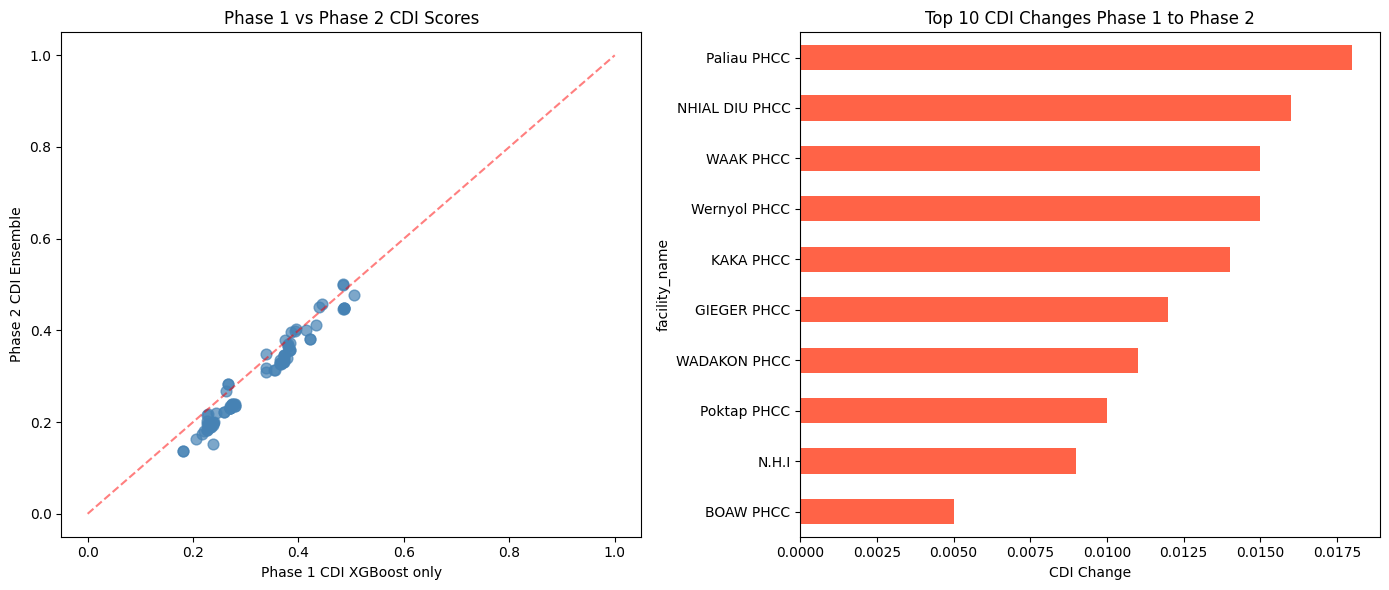

In [39]:
phase1_path = '/kaggle/input/datasets/mubarakabanadda/phase1-scores/SSD_CDI_Scores_Phase1.csv'
if os.path.exists(phase1_path):
    cdi_phase1 = pd.read_csv(phase1_path)
    comparison = cdi_ensemble[['facility_name', 'CDI']].merge(
        cdi_phase1[['facility_name', 'CDI']].rename(columns={'CDI': 'CDI_phase1'}),
        on='facility_name', how='left'
    )
    comparison['CDI_change'] = comparison['CDI'] - comparison['CDI_phase1']

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].scatter(comparison['CDI_phase1'], comparison['CDI'],
                    alpha=0.7, color='steelblue', s=60)
    axes[0].plot([0, 1], [0, 1], 'r--', alpha=0.5)
    axes[0].set_xlabel('Phase 1 CDI XGBoost only')
    axes[0].set_ylabel('Phase 2 CDI Ensemble')
    axes[0].set_title('Phase 1 vs Phase 2 CDI Scores')
    comparison.sort_values('CDI_change').tail(10).set_index('facility_name')['CDI_change'].plot(
        kind='barh', ax=axes[1], color='tomato'
    )
    axes[1].set_title('Top 10 CDI Changes Phase 1 to Phase 2')
    axes[1].set_xlabel('CDI Change')
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/phase1_vs_phase2.png', dpi=150)
    plt.show()
else:
    print('Phase 1 scores not found, skipping comparison')

## 10. Visualise Ensemble Results

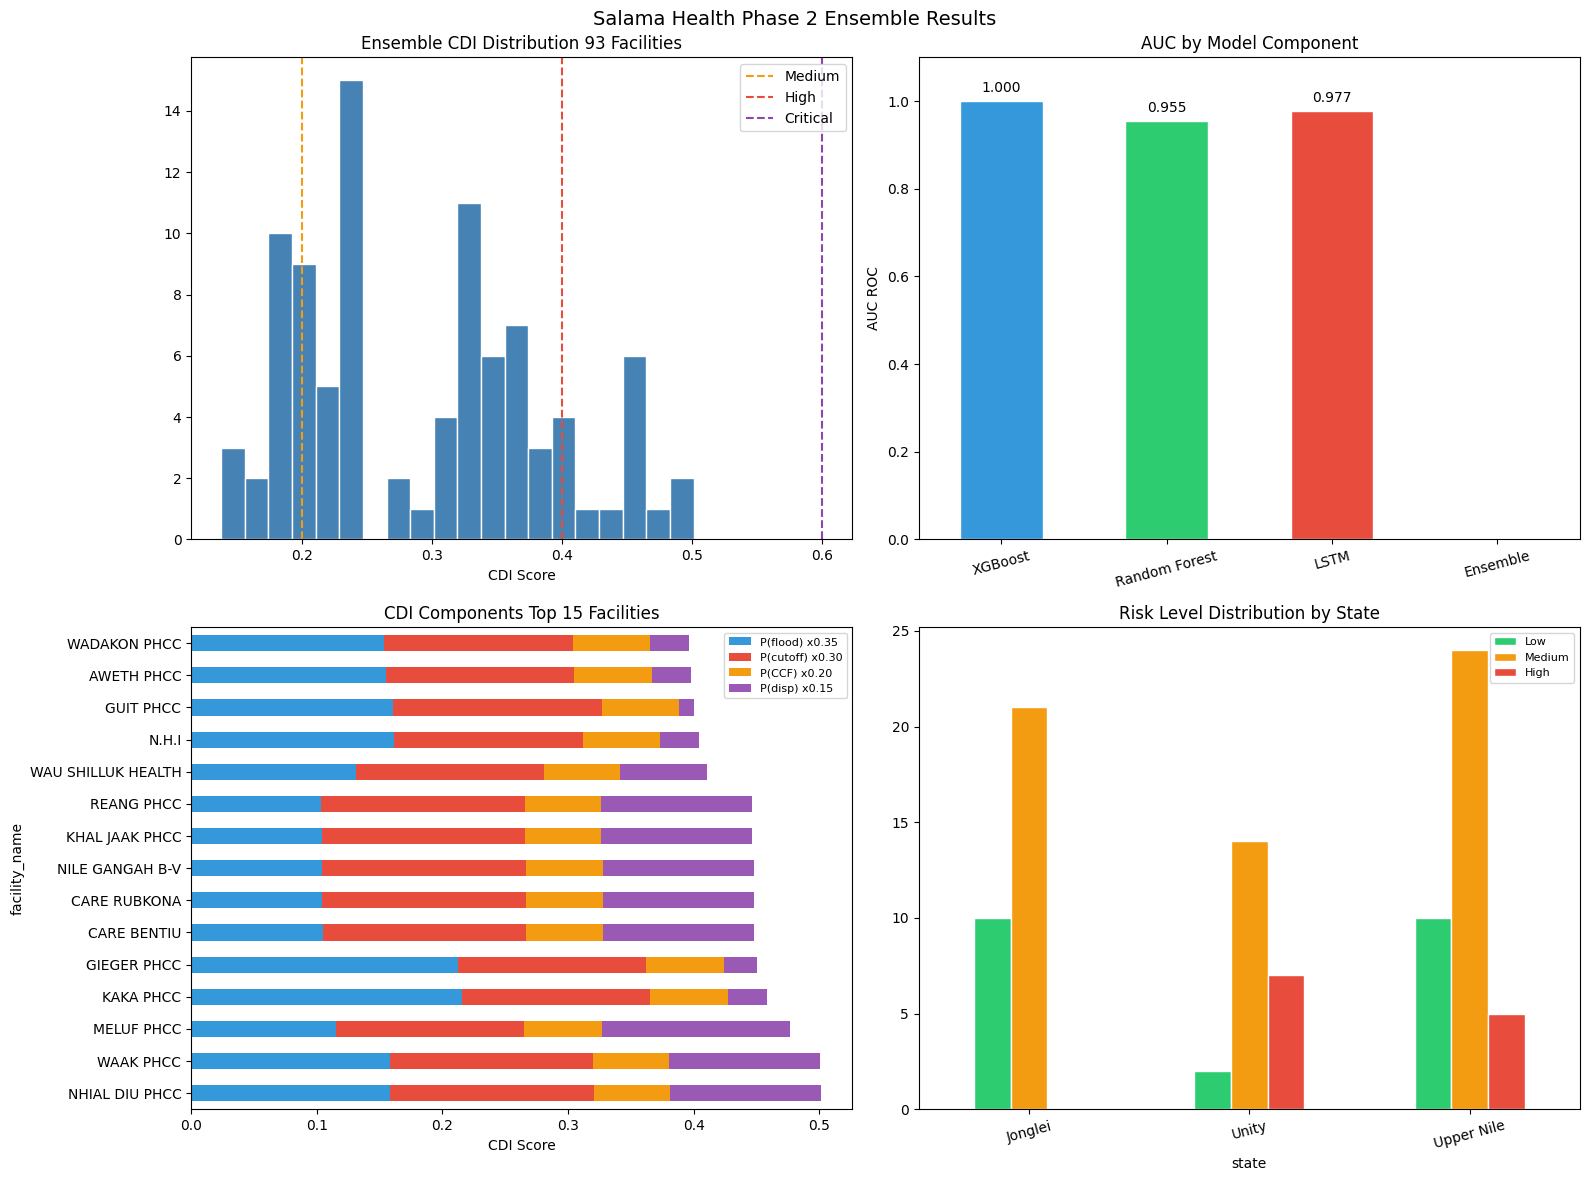

Charts saved


In [37]:
palette = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c', 'Critical': '#8e44ad'}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].hist(cdi_ensemble['CDI'], bins=20, color='steelblue', edgecolor='white')
axes[0, 0].axvline(0.20, color='#f39c12', linestyle='--', label='Medium')
axes[0, 0].axvline(0.40, color='#e74c3c', linestyle='--', label='High')
axes[0, 0].axvline(0.60, color='#8e44ad', linestyle='--', label='Critical')
axes[0, 0].set_title('Ensemble CDI Distribution 93 Facilities')
axes[0, 0].set_xlabel('CDI Score')
axes[0, 0].legend()

model_aucs = {
    'XGBoost':       xgb_auc_oof,
    'Random Forest': rf_auc_oof,
    'LSTM':          lstm_auc_oof,
    'Ensemble':      ensemble_auc
}
pd.Series(model_aucs).plot(
    kind='bar', ax=axes[0, 1],
    color=['#3498db', '#2ecc71', '#e74c3c', '#9b59b6'],
    edgecolor='white'
)
axes[0, 1].set_title('AUC by Model Component')
axes[0, 1].set_ylabel('AUC ROC')
axes[0, 1].tick_params(axis='x', rotation=15)
axes[0, 1].set_ylim(0, 1.1)
for i, v in enumerate(model_aucs.values()):
    axes[0, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=10)

top15 = cdi_ensemble.head(15).set_index('facility_name')
components = pd.DataFrame({
    'P(flood) x0.35':  top15['P_flood']  * 0.35,
    'P(cutoff) x0.30': top15['P_cutoff'] * 0.30,
    'P(CCF) x0.20':    top15['P_CCF']    * 0.20,
    'P(disp) x0.15':   top15['P_disp']   * 0.15,
})
components.plot(
    kind='barh', stacked=True, ax=axes[1, 0],
    color=['#3498db', '#e74c3c', '#f39c12', '#9b59b6']
)
axes[1, 0].set_title('CDI Components Top 15 Facilities')
axes[1, 0].set_xlabel('CDI Score')
axes[1, 0].legend(fontsize=8)

state_risk = cdi_ensemble.groupby(['state', 'risk_level'], observed=True).size().unstack(fill_value=0)
state_risk.plot(
    kind='bar', ax=axes[1, 1],
    color=[palette.get(c, 'grey') for c in state_risk.columns],
    edgecolor='white'
)
axes[1, 1].set_title('Risk Level Distribution by State')
axes[1, 1].tick_params(axis='x', rotation=15)
axes[1, 1].legend(fontsize=8)

plt.suptitle('Salama Health Phase 2 Ensemble Results', fontsize=14)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/ensemble_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Charts saved')

## 11. Save All Outputs

In [38]:
cdi_ensemble.to_csv(f'{OUT_DIR}/SSD_CDI_Scores_Phase2.csv', index=False)
print(f'CDI scores saved: {len(cdi_ensemble)} facilities')

with open(f'{OUT_DIR}/SSD_RF_Model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
torch.save(lstm_model.state_dict(), f'{OUT_DIR}/SSD_LSTM_Model.pt')
print('All models saved')

ensemble_weights = {'xgb': round(xgb_w, 4), 'rf': round(rf_w, 4), 'lstm': round(lstm_w, 4)}
with open(f'{OUT_DIR}/ensemble_weights.json', 'w') as f:
    json.dump(ensemble_weights, f, indent=2)

metrics = {
    'xgb_auc':        round(xgb_auc_oof, 4),
    'rf_auc':         round(rf_auc_oof, 4),
    'lstm_auc':       round(lstm_auc_oof, 4),
    'ensemble_auc':   round(ensemble_auc, 4),
    'ensemble_f1':    round(ensemble_f1, 4),
    'ensemble_weights': ensemble_weights,
    'facilities':     int(cdi_ensemble['facility_name'].nunique()),
    'high_risk':      int((cdi_ensemble['risk_level'] == 'High').sum()),
    'critical_risk':  int((cdi_ensemble['risk_level'] == 'Critical').sum()),
    'top_facility':   cdi_ensemble.iloc[0]['facility_name'],
    'top_cdi':        float(cdi_ensemble.iloc[0]['CDI']),
}
with open(f'{OUT_DIR}/model_metrics_phase2.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('Metrics saved')

print('\nPhase 2 Summary')
print(f'XGBoost AUC:       {metrics["xgb_auc"]}')
print(f'Random Forest AUC: {metrics["rf_auc"]}')
print(f'LSTM AUC:          {metrics["lstm_auc"]}')
print(f'Ensemble AUC:      {metrics["ensemble_auc"]}')
print(f'Ensemble F1:       {metrics["ensemble_f1"]}')
print(f'Ensemble weights:  XGB {xgb_w:.3f} | RF {rf_w:.3f} | LSTM {lstm_w:.3f}')
print(f'Facilities:        {metrics["facilities"]}')
print(f'High risk:         {metrics["high_risk"]}')
print(f'Critical risk:     {metrics["critical_risk"]}')
print(f'Top facility:      {metrics["top_facility"]} CDI {metrics["top_cdi"]}')
print(f'Outputs saved to: {OUT_DIR}')

CDI scores saved: 93 facilities
All models saved
Metrics saved

Phase 2 Summary
XGBoost AUC:       1.0
Random Forest AUC: 0.9548
LSTM AUC:          0.9775
Ensemble AUC:      nan
Ensemble F1:       0.0
Ensemble weights:  XGB 0.341 | RF 0.326 | LSTM 0.333
Facilities:        93
High risk:         12
Critical risk:     0
Top facility:      NHIAL DIU PHCC CDI 0.501
Outputs saved to: /kaggle/working
